# **EDA of the WWF LPD 2024 Data**

This notebook extends the existing biodiversity forecasting pipeline and modeling logic from `Model_Dataset_Building&Evaluation.ipynb` by integrating climate variables into the modeling dataset.

The goal is to test whether climate information — starting with annual temperature — helps explain or predict biodiversity population trends beyond lagged population dynamics alone.

This notebook is designed to stay consistent with the existing modeling workflow while remaining modular, so additional climate variables (for example precipitation, drought, or anomalies) can be added later with minimal changes.

---
# **1 - INTRO**

### 1.1 - OBJECTIVE

- reuse the same long-format + lag-feature pipeline as in `Model_Dataset_Building&Evaluation.ipynb`
- start with a **temperature** feature at the **country-year** level
- keep the pipeline modular so more climate variables can be added later
- compare:
  1. **baseline model** (original features only)
  2. **climate-augmented model** (original + climate features)

**Why start with annual temperature?**

A country-year annual temperature series is the cleanest first integration because the biodiversity benchmark already operates at a yearly resolution and includes a `country` field for many records. That makes the first merge interpretable and easy to audit.

**Notebook design**

This notebook distinguishes between two complementary goals:

*A. Forecasting*

Use lagged population history and metadata to maximize short-horizon predictive performance.

*B. Climate interpretation*

Assess whether climate variables provide additional predictive or explanatory information, especially when lag features are reduced or removed.

This distinction matters because the strongest forecasting model is not always the most interpretable climate model.

### 1.2 - WORKFLOW

The team’s main modeling workflow already builds short-horizon forecasting models using lagged population history and metadata.  
This notebook adds a modular climate integration layer that can later be extended with additional climate covariates such as precipitation, anomalies, drought indicators, or variability measures.

- loads one cleaned biodiversity dataset
- reshapes the data from wide to long format
- downloads and prepares annual country-level temperature data
- merges biodiversity and climate observations by `country` and `year`
- builds modular feature sets
- compares three modeling settings:
  1. forecasting baseline
  2. forecasting + temperature
  3. lag-free climate explanatory setting
- demonstrates one application example for a single monitored population

### 1.3 - RESEARCH QUESTIONS

1. Does annual temperature improve short-horizon biodiversity forecasting beyond lagged population history?
2. Does temperature retain predictive relevance when lag features are removed?
3. Can climate inputs be translated into an interpretable population-level contribution signal for a future API/UI?

---
# **2 - SETUP**

**Notes before running**
- It downloads temperature data from **Our World in Data's country-level annual surface temperature series**, which is based on **ERA5 monthly averaged data** with country-level processing.  
- If country names do not match perfectly between your biodiversity dataset and the climate dataset, use the `COUNTRY_NAME_FIXES` dictionary below.

### 2.1 - IMPORTS

We keep the structure close to the main modeling notebook:
- same basic preprocessing logic
- same lag-based time-series framing
- same temporal train/test split
- climate data stored separately in `data/external/climate`
- future climate covariates/variables can be added with minimal changes

In [1]:
from pathlib import Path
import warnings
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

### 2.2 - PATHS & GLOBAL CONFIGURATION

In [2]:
# --- Project paths ---
PROJECT_ROOT = Path("..").resolve()

DATA_INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
DATA_EXTERNAL_CLIMATE_DIR = PROJECT_ROOT / "data" / "external" / "climate"
DATA_EXTERNAL_CLIMATE_DIR.mkdir(parents=True, exist_ok=True)

# --- Main biodiversity dataset ---
DATA_PATH = DATA_INTERIM_DIR / "strict_forecasting" /  "lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv"

# --- Climate data paths ---
TEMP_FILE = DATA_EXTERNAL_CLIMATE_DIR / "average-annual-surface-temperature.csv"
OWID_TEMP_URL = "https://ourworldindata.org/grapher/average-annual-surface-temperature.csv"

# --- Modeling settings ---
N_LAGS = 4
TEST_YEARS = 5
RANDOM_STATE = 42

print("Project root:", PROJECT_ROOT)
print("Biodiversity dataset:", DATA_PATH)
print("Climate folder:", DATA_EXTERNAL_CLIMATE_DIR)

Project root: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction
Biodiversity dataset: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\strict_forecasting\lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv
Climate folder: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\external\climate


---
# **3 - BIODIVERSITY DATA**

The cleaned biodiversity dataset is expected in wide format, with one column per year and one row per monitored population.

In [3]:
df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
display(df_raw.head())

(49, 126)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group
0,27563,Gulo_gulo,0,1,"Kojola, I., S. Heikkinen, S. Mäntyniemi and T....",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Finland (inside reindeer areas),finland,Finland,Europe,Europe and Central Asia,Central and Western Europe,65.366353,28.516576,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.1429,5.4622,3.5247,3.2330,3.5247,3.5247,9.2437,8.1933,9.0686,13.8655,7.1429,9.6639,8.1933,5.8590,5.8824,14.6125,22.2689,20.7400,22.6891,37.3950,36.1345,50.5019,58.8235,37.3950,37.3950,54.2017,59.2437,57.9832,61.7647,92.437,74.3697,100.0000,1,NaN,32.0,1989.0,2020.0,32.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
1,27564,Gulo_gulo,0,1,"Kojola, I., S. Heikkinen, S. Mäntyniemi and T....",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Finland (outside reindeer areas),finland,Finland,Europe,Europe and Central Asia,Central and Western Europe,65.366353,28.516576,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0769,17.5824,18.6813,18.6813,24.1758,29.6703,31.8681,30.7692,38.4615,40.6593,37.3626,41.7582,46.1538,48.3516,72.5275,76.9231,92.3077,91.2088,90.1099,104.3956,105.4945,120.8791,136.2637,118.6813,135.1648,164.8352,200.0000,218.6813,236.2637,267.033,253.8462,327.4725,1,NaN,32.0,1989.0,2020.0,32.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
2,27565,Gulo_gulo,0,1,"Mattisson, J., L. Höglund and H. Brøseth (2020...",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Sweden,sweden,Sweden,Europe,Europe and Central Asia,Central and Western Europe,64.444593,15.165737,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,398.0000,380.0000,328.0000,319.0000,313.0000,343.0000,386.0000,431.0000,425.0000,444.0000,511.0000,575.0000,654.0000,669.0000,751.0000,715.0000,648.0000,587.0000,498.0000,523.0000,584.000,676.0000,687.0000,1,NaN,23.0,1998.0,2020.0,23.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
3,27566,Gulo_gulo,0,1,"Mattisson, J., L. Höglund and H. Brøseth (2020...",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Norway,norway,Norway,Europe,Europe and Central Asia,Central and Western Europe,64.867984,12.439186,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

We separate:
- year columns
- identifiers
- static numeric features
- static categorical features
- leakage columns not to be used directly as predictors

In [4]:
reference_columns = list(df_raw.columns)
year_columns = [col for col in reference_columns if str(col).isdigit()]
reference_columns_set = set(reference_columns)

static_numeric_features = ["latitude", "longitude"]

static_categorical_features = [
    "class",
    "family",
    "ipbes_subregion",
    "system_group",
    "t_realm",
    "t_biome",
    "units"
]

identifier_columns = ["id", "binomial", "common_name", "location", "country"]

leakage_columns = [
    "n_obs",
    "first_obs_year",
    "last_obs_year",
    "time_span",
    "n_gaps",
    "max_gap",
    "continuity_ratio",
    "zero_count",
    "zero_share",
    "years_since_last_obs"
]

static_numeric_features = [c for c in static_numeric_features if c in reference_columns_set]
static_categorical_features = [c for c in static_categorical_features if c in reference_columns_set]
identifier_columns = [c for c in identifier_columns if c in reference_columns_set]
leakage_columns = [c for c in leakage_columns if c in reference_columns_set]

print("Number of year columns:", len(year_columns))
print("Static numeric features:", static_numeric_features)
print("Static categorical features:", static_categorical_features)
print("Identifier columns:", identifier_columns)
print("Leakage columns:", leakage_columns)

Number of year columns: 71
Static numeric features: ['latitude', 'longitude']
Static categorical features: ['class', 'family', 'ipbes_subregion', 'system_group', 't_realm', 't_biome', 'units']
Identifier columns: ['id', 'binomial', 'common_name', 'location', 'country']
Leakage columns: ['n_obs', 'first_obs_year', 'last_obs_year', 'time_span', 'n_gaps', 'max_gap', 'continuity_ratio', 'zero_count', 'zero_share', 'years_since_last_obs']


These helpers reproduce the main data preparation logic of the short-horizon modeling workflow:
- construct a `series_id`
- reshape the dataset into long format
- evaluate predictions
- split train and test temporally

In [5]:
def build_series_id(df):
    parts = []

    if "common_name" in df.columns:
        parts.append(df["common_name"].astype(str))
    elif "binomial" in df.columns:
        parts.append(df["binomial"].astype(str))

    if "country" in df.columns:
        parts.append(df["country"].astype(str))

    if len(parts) == 0:
        return pd.Series(np.arange(len(df)).astype(str), index=df.index)

    series_id = parts[0]
    for p in parts[1:]:
        series_id = series_id + "|" + p

    return series_id

In [6]:
def wide_to_long(df, year_columns):
    id_columns = [col for col in df.columns if col not in year_columns]

    long_df = df.melt(
        id_vars=id_columns,
        value_vars=year_columns,
        var_name="Year",
        value_name="Population"
    ).dropna(subset=["Population"]).copy()

    long_df["Year"] = long_df["Year"].astype(int)
    long_df["series_id"] = build_series_id(long_df)
    long_df["log_population"] = np.log1p(long_df["Population"])

    return long_df

In [7]:
def temporal_split(df, test_years=5):
    years = sorted(df["Year"].unique())
    test_year_values = years[-test_years:]

    train_df = df[df["Year"] < min(test_year_values)].copy().reset_index(drop=True)
    test_df = df[df["Year"].isin(test_year_values)].copy().reset_index(drop=True)

    return train_df, test_df, test_year_values

In [8]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mean_abs_true = np.mean(np.abs(y_true))
    nmae = mae / mean_abs_true if mean_abs_true != 0 else np.nan

    denom = np.sum(np.abs(y_true))
    wape = np.sum(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan

    smape_denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = smape_denom != 0
    smape = np.mean(
        np.abs(y_true[valid] - y_pred[valid]) / smape_denom[valid]
    ) if np.any(valid) else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "NMAE": nmae,
        "WAPE": wape,
        "sMAPE": smape
    }

We start with annual country-level surface temperature.

This is a practical first climate covariate because:
- it is available at yearly resolution
- it aligns naturally with the biodiversity panel by `country + year`
- it provides a modular template for future climate data integration

The current implementation focuses on temperature, but the same pipeline can later be extended to precipitation, anomalies, variability, or extremes.

The file is stored in:

`data/external/climate/average-annual-surface-temperature.csv`

A browser-style user-agent is used to avoid HTTP blocking issues.

In [9]:
def download_file(url, destination):
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/122.0.0.0 Safari/537.36"
        )
    }

    response = requests.get(url, headers=headers, timeout=60)
    response.raise_for_status()

    destination.parent.mkdir(parents=True, exist_ok=True)
    with open(destination, "wb") as f:
        f.write(response.content)

    return destination

In [10]:
if not TEMP_FILE.exists():
    print("Downloading temperature data...")
    download_file(OWID_TEMP_URL, TEMP_FILE)
    print("Saved to:", TEMP_FILE)
else:
    print("Temperature file already exists:", TEMP_FILE)

Temperature file already exists: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\external\climate\average-annual-surface-temperature.csv


In [11]:
temp_raw = pd.read_csv(TEMP_FILE)
print(f"Loaded temperature data from: {TEMP_FILE}")
print(f"Rows: {len(temp_raw):,} | Columns: {len(temp_raw.columns)}")
display(temp_raw.head())
print(temp_raw.columns.tolist())

Loaded temperature data from: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\external\climate\average-annual-surface-temperature.csv
Rows: 18,318 | Columns: 4


,Entity,Code,Year,Average surface temperature
0,Afghanistan,AFG,1940,11.327695
1,Afghanistan,AFG,1941,13.324756
2,Afghanistan,AFG,1942,12.885448
3,Afghanistan,AFG,1943,11.524769
4,Afghanistan,AFG,1944,12.143665


['Entity', 'Code', 'Year', 'Average surface temperature']


We standardize the temperature file into a clean country-year panel with:
- `country_climate`
- `Year`
- `temp_avg_c`

In [12]:
def prepare_temperature_data(temp_raw):
    temp_df = temp_raw.copy()

    value_candidates = [c for c in temp_df.columns if c not in ["Entity", "Code", "Year"]]
    if len(value_candidates) != 1:
        raise ValueError(f"Unexpected temperature schema. Value columns found: {value_candidates}")

    value_col = value_candidates[0]

    temp_df = temp_df.rename(columns={
        "Entity": "country_climate",
        "Year": "Year",
        value_col: "temp_avg_c"
    })

    temp_df = temp_df[["country_climate", "Code", "Year", "temp_avg_c"]].copy()
    temp_df["Year"] = temp_df["Year"].astype(int)
    temp_df["temp_avg_c"] = pd.to_numeric(temp_df["temp_avg_c"], errors="coerce")

    return temp_df

In [13]:
temp_df = prepare_temperature_data(temp_raw)
print(temp_df.shape)
display(temp_df.head())
print("Temperature year range:", temp_df["Year"].min(), "-", temp_df["Year"].max())

(18318, 4)


,country_climate,Code,Year,temp_avg_c
0,Afghanistan,AFG,1940,11.327695
1,Afghanistan,AFG,1941,13.324756
2,Afghanistan,AFG,1942,12.885448
3,Afghanistan,AFG,1943,11.524769
4,Afghanistan,AFG,1944,12.143665


Temperature year range: 1940 - 2025


### ?.? - COUNTRY HARMONIZATION

Country names can differ across biodiversity and climate datasets.

To merge robustly, we:
- strip whitespace
- convert to lowercase
- apply manual harmonization rules

In [14]:
def normalize_country_name(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    country_fixes = {
        "usa": "united states",
        "us": "united states",
        "u.s.a.": "united states",
        "u.s.": "united states",
        "uk": "united kingdom",
        "czech republic": "czechia",
        "viet nam": "vietnam",
        "democratic republic of the congo": "democratic republic of congo",
        "republic of the congo": "congo",
        "swaziland": "eswatini",
        "russian federation": "russia",
    }

    return country_fixes.get(x, x)

### ?.? - BUILD BIO-DIVERSITY LONG PANEL

In [15]:
bio_long = wide_to_long(df_raw, year_columns)

if "country" not in bio_long.columns:
    raise ValueError("The biodiversity dataset must contain a 'country' column for country-level climate merging.")

bio_long["country_norm"] = bio_long["country"].apply(normalize_country_name)

print(bio_long.shape)
display(bio_long.head())
print("Biodiversity year range:", bio_long["Year"].min(), "-", bio_long["Year"].max())

(1349, 60)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,Year,Population,series_id,log_population,country_norm
1479,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,36.0,Yellow-footed Rock-wallaby|australia,3.610918,australia
1480,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,20.0,Yellow-footed Rock-wallaby|australia,3.044522,australia
1523,27730,Alces_americanus,0,1,Kluane National Park (2017) ‘Moose Survey Coun...,Mammalia,Artiodactyla,Cervidae,Alces,americanus,NaN,Moose,"Duke, Kluane National Park and Reserve, Yukon",canada,Canada,North America,Americas,North America,60.749785,-139.500032,1,terrestrial,Nearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,adult individuals (bulls and cows),1,NaN,36.0,1981.0,2020.0,40.0,4.0,1.0,0.90000,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,81.0,Moose|canada,4.406719,canada
1528,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,21.0,Yellow-footed Rock-wallaby|australia,3.091042,australia
1529,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,28.0,Yellow-footed Rock-wallaby|australia,3.367296,australia


Biodiversity year range: 1980 - 2020


Prepare climate merge table

In [16]:
temp_df["country_norm"] = temp_df["country_climate"].apply(normalize_country_name)
temp_merge = temp_df[["country_norm", "Year", "temp_avg_c"]].copy()

print(temp_merge.shape)
display(temp_merge.head())

(18318, 3)


,country_norm,Year,temp_avg_c
0,afghanistan,1940,11.327695
1,afghanistan,1941,13.324756
2,afghanistan,1942,12.885448
3,afghanistan,1943,11.524769
4,afghanistan,1944,12.143665


Before merging, we inspect country overlap to identify mismatches.

In [17]:
bio_countries = set(bio_long["country_norm"].dropna().unique())
climate_countries = set(temp_merge["country_norm"].dropna().unique())

print("Countries in biodiversity:", len(bio_countries))
print("Countries in climate:", len(climate_countries))
print("Overlap:", len(bio_countries & climate_countries))

Countries in biodiversity: 5
Countries in climate: 213
Overlap: 5


In [18]:
print("Countries in biodiversity but not climate:")
display(sorted(bio_countries - climate_countries)[:50])

Countries in biodiversity but not climate:


[]

In [19]:
print("Countries in climate but not biodiversity:")
display(sorted(climate_countries - bio_countries)[:50])

Countries in climate but not biodiversity:


['afghanistan',
 'africa (niaid)',
 'albania',
 'algeria',
 'american samoa',
 'andorra',
 'angola',
 'anguilla',
 'antarctica (niaid)',
 'antigua and barbuda',
 'arctic ocean (niaid)',
 'argentina',
 'armenia',
 'asia (niaid)',
 'australia (niaid)',
 'austria',
 'azerbaijan',
 'bahamas',
 'bahrain',
 'baltic sea (niaid)',
 'bangladesh',
 'belarus',
 'belgium',
 'belize',
 'benin',
 'bhutan',
 'bolivia',
 'bosnia and herzegovina',
 'botswana',
 'brazil',
 'brunei',
 'bulgaria',
 'burkina faso',
 'burundi',
 'cambodia',
 'cameroon',
 'cape verde',
 'cayman islands',
 'central african republic',
 'chad',
 'chile',
 'china',
 'colombia',
 'comoros',
 'congo',
 'cook islands',
 'costa rica',
 "cote d'ivoire",
 'croatia',
 'cuba']

We start with annual average temperature and derive several modular climate features:
- current temperature
- lagged temperature
- year-to-year change
- rolling mean
- rolling variability
- anomaly relative to country baseline

These features can later be replicated for additional climate variables.

In [20]:
def add_temperature_features(df, country_col="country_norm", year_col="Year", temp_col="temp_avg_c"):
    df = df.sort_values([country_col, year_col]).copy()

    grouped = df.groupby(country_col)[temp_col]

    df["temp_lag_1"] = grouped.shift(1)
    df["temp_lag_2"] = grouped.shift(2)

    df["temp_change_1y"] = df[temp_col] - df["temp_lag_1"]

    df["temp_rolling_mean_3"] = (
        grouped.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
    )

    df["temp_rolling_std_3"] = (
        grouped.shift(1).rolling(3).std().reset_index(level=0, drop=True)
    )

    country_mean = df.groupby(country_col)[temp_col].transform("mean")
    df["temp_anomaly_vs_country_mean"] = df[temp_col] - country_mean

    return df

In [21]:
temp_features = add_temperature_features(temp_merge)
print(temp_features.shape)
display(temp_features.head(10))

(18318, 9)


,country_norm,Year,temp_avg_c,temp_lag_1,temp_lag_2,temp_change_1y,temp_rolling_mean_3,temp_rolling_std_3,temp_anomaly_vs_country_mean
0,afghanistan,1940,11.327695,NaN,NaN,NaN,NaN,NaN,-0.753880
1,afghanistan,1941,13.324756,11.327695,NaN,1.997061,NaN,NaN,1.243181
2,afghanistan,1942,12.885448,13.324756,11.327695,-0.439308,NaN,NaN,0.803873
3,afghanistan,1943,11.524769,12.885448,13.324756,-1.360679,12.512633,1.049431,-0.556806
4,afghanistan,1944,12.143665,11.524769,12.885448,0.618896,12.578324,0.938473,0.062090
5,afghanistan,1945,11.366585,12.143665,11.524769,-0.777080,12.184627,0.681264,-0.714990
6,afghanistan,1946,12.438739,11.366585,12.143665,1.072154,11.678340,0.410672,0.357164
7,afghanistan,1947,12.343286,12.438739,11.366585,-0.095453,11.982996,0.553841,0.261711
8,afghanistan,1948,11.804020,12.343286,12.438739,-0.539266,12.049537,0.593376,-0.277555
9,afghanistan,1949,10.509593,11.804020,12.343286,-1.294427,12.195348,0.342244,-1.571982


## 15. Merge biodiversity and climate data

The merge is done on:
- normalized country name
- year

In [22]:
model_long = bio_long.merge(
    temp_features,
    on=["country_norm", "Year"],
    how="left"
)

print(model_long.shape)
display(model_long.head())

(1349, 67)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,Year,Population,series_id,log_population,country_norm,temp_avg_c,temp_lag_1,temp_lag_2,temp_change_1y,temp_rolling_mean_3,temp_rolling_std_3,temp_anomaly_vs_country_mean
0,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,36.0,Yellow-footed Rock-wallaby|australia,3.610918,australia,22.476896,22.050299,21.344397,0.426597,21.679944,0.354236,0.494948
1,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,20.0,Yellow-footed Rock-wallaby|australia,3.044522,australia,22.476896,22.050299,21.344397,0.426597,21.679944,0.354236,0.494948
2,27730,Alces_americanus,0,1,Kluane National Park (2017) ‘Moose Survey Coun...,Mammalia,Artiodactyla,Cervidae,Alces,americanus,NaN,Moose,"Duke, Kluane National Park and Reserve, Yukon",canada,Canada,North America,Americas,North America,60.749785,-139.500032,1,terrestrial,Nearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,adult individuals (bulls and cows),1,NaN,36.0,1981.0,2020.0,40.0,4.0,1.0,0.90000,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,81.0,Moose|canada,4.406719,canada,-2.742507,-4.342841,-4.942274,1.600334,-4.868103,0.492384,1.499136
3,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,21.0,Yellow-footed Rock-wallaby|australia,3.091042,australia,21.975897,22.476896,22.050299,-0.500999,21.957197,0.571961,-0.006051
4,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,28.0,Yellow-footed Rock-wallaby|australia,3.367296,australia,21.975897,22.476896,22.050299,-0.500999,21.957197,0.571961,-0.006051


In [23]:
merge_summary = pd.DataFrame({
    "rows_total": [len(model_long)],
    "rows_with_temp": [model_long["temp_avg_c"].notna().sum()],
    "rows_missing_temp": [model_long["temp_avg_c"].isna().sum()],
    "share_with_temp": [model_long["temp_avg_c"].notna().mean()]
})

display(merge_summary)

,rows_total,rows_with_temp,rows_missing_temp,share_with_temp
0,1349,1349,0,1.0


In [24]:
missing_countries = (
    model_long.loc[model_long["temp_avg_c"].isna(), "country_norm"]
    .dropna()
    .value_counts()
    .head(30)
)

display(missing_countries)

Series([], Name: count, dtype: int64)

In [25]:
print("MODEL_LONG SHAPE:", model_long.shape)
print("\nCOLUMNS:")
print(sorted(model_long.columns.tolist()))

print("\nYEAR RANGE:")
print(model_long["Year"].min(), model_long["Year"].max())

print("\nN UNIQUE SERIES:")
print(model_long["series_id"].nunique())

print("\nROWS WITH TEMP:")
print(model_long["temp_avg_c"].notna().sum())

print("\nTEMP COVERAGE:")
print(model_long["temp_avg_c"].notna().mean())

MODEL_LONG SHAPE: (1349, 67)

COLUMNS:
['Population', 'Year', 'all_countries', 'binomial', 'citation', 'class', 'common_name', 'continuity_ratio', 'country', 'country_norm', 'family', 'first_obs_year', 'fw_biome', 'fw_realm', 'genus', 'has_binomial', 'has_class', 'has_coordinates', 'has_country', 'has_family', 'has_genus', 'has_order', 'has_species', 'has_taxonomy_hierarchy', 'has_valid_coordinates', 'id', 'included_in_lpr2024', 'ipbes_region', 'ipbes_subregion', 'last_obs_year', 'latitude', 'location', 'log_population', 'longitude', 'm_biome', 'm_ocean', 'm_realm', 'max_gap', 'n_gaps', 'n_obs', 'native', 'order', 'region', 'replicate', 'series_id', 'species', 'specific_location', 'subspecies', 'system', 'system_group', 't_biome', 't_realm', 'temp_anomaly_vs_country_mean', 'temp_avg_c', 'temp_change_1y', 'temp_lag_1', 'temp_lag_2', 'temp_rolling_mean_3', 'temp_rolling_std_3', 'time_span', 'unit_category', 'unit_usable', 'units', 'unnamed_102', 'years_since_last_obs', 'zero_count', 'zer

## 16. Population dynamics feature engineering

We reproduce the main short-horizon forecasting logic by constructing lag-based and trend-based features from population history.

In [26]:
def add_lag_features(long_df, n_lags=4):
    long_df = long_df.sort_values(["series_id", "Year"]).copy()
    grouped_pop = long_df.groupby("series_id")["Population"]

    for lag in range(1, n_lags + 1):
        long_df[f"lag_{lag}"] = grouped_pop.shift(lag)

    long_df["prev_year"] = long_df.groupby("series_id")["Year"].shift(1)
    long_df["year_gap_from_prev"] = long_df["Year"] - long_df["prev_year"]

    long_df["rolling_mean_3"] = (
        grouped_pop.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
    )

    long_df["rolling_std_3"] = (
        grouped_pop.shift(1).rolling(3).std().reset_index(level=0, drop=True)
    )

    long_df["population_difference"] = long_df["lag_1"] - long_df["lag_2"]

    long_df["population_growth_rate"] = (
        (long_df["lag_1"] - long_df["lag_2"]) /
        long_df["lag_2"].replace(0, np.nan)
    )
    long_df["population_growth_rate"] = long_df["population_growth_rate"].replace(
        [np.inf, -np.inf], np.nan
    )

    needed = [f"lag_{lag}" for lag in range(1, n_lags + 1)]
    long_df = long_df.dropna(subset=needed).copy()

    return long_df

In [27]:
model_long = add_lag_features(model_long, n_lags=N_LAGS)
print(model_long.shape)
display(model_long.head())

(1309, 77)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,Year,Population,series_id,log_population,country_norm,temp_avg_c,temp_lag_1,temp_lag_2,temp_change_1y,temp_rolling_mean_3,temp_rolling_std_3,temp_anomaly_vs_country_mean,lag_1,lag_2,lag_3,lag_4,prev_year,year_gap_from_prev,rolling_mean_3,rolling_std_3,population_difference,population_growth_rate
140,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,31.0,1990.0,2020.0,31.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1994,99.0,Helmeted Honeyeater|australia,4.605170,australia,22.029740,21.976034,21.666819,0.053706,21.990867,0.331713,0.047792,85.0,75.0,66.0,70.0,1993.0,1.0,1.666667,1.154701,10.0,0.133333
173,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,31.0,1990.0,2020.0,31.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1995,100.0,Helmeted Honeyeater|australia,4.615121,australia,21.740072,22.029740,21.976034,-0.289668,21.890864,0.195878,-0.241876,99.0,85.0,75.0,66.0,1994.0,1.0,4.666667,4.041452,14.0,0.164706
212,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,31.0,1990.0,2020.0,31.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1996,105.0,Helmeted Honeyeater|australia,4.663439,australia,22.214340,21.740072,22.029740,0.474268,21.915282,0.154094,0.232392,100.0,99.0,85.0,75.0,1995.0,1.0,1.333333,1.527525,1.0,0.010101
251,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,31.0,1990.0,2020.0,31.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1997,95.0,Helmeted Honeyeater|australia,4.564348,australia,21.928260,22.214340,21.740072,-0.286080,21.994717,0.239066,-0.053688,105.0,100.0,99.0,85.0,1996.0,1.0,5.666667,2.886751,5.0,0.050000
293,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,

## 17. Experiment design

We evaluate three settings:

### 1. forecast_baseline
Lag-based forecasting using population history and metadata.

### 2. forecast_plus_temperature
Same forecasting setting, with temperature features added.

### 3. climate_explanatory
No population lags, using metadata and climate covariates only.

This helps separate predictive performance from climate interpretability.

In [28]:
EXPERIMENTS = {
    "forecast_baseline": {
        "include_lags": True,
        "include_climate": False,
        "description": "Lag-based forecasting baseline"
    },
    "forecast_plus_temperature": {
        "include_lags": True,
        "include_climate": True,
        "description": "Lag-based forecasting with temperature"
    },
    "climate_explanatory": {
        "include_lags": False,
        "include_climate": True,
        "description": "No population lags, climate + metadata only"
    }
}

## 18. Modular feature-set builder

Feature sets are constructed dynamically so that future climate variables can be added centrally without rewriting the notebook.

In [29]:
def build_feature_columns(
    df,
    include_lags=True,
    include_climate=True,
    static_numeric_features=None,
    static_categorical_features=None,
    n_lags=4
):
    static_numeric_features = static_numeric_features or []
    static_categorical_features = static_categorical_features or []

    common_numeric = ["Year"] + [c for c in static_numeric_features if c in df.columns]

    lag_numeric = [
        *[f"lag_{i}" for i in range(1, n_lags + 1)],
        "year_gap_from_prev",
        "rolling_mean_3",
        "rolling_std_3",
        "population_difference",
        "population_growth_rate",
    ]
    lag_numeric = [c for c in lag_numeric if c in df.columns]

    climate_numeric = [
        "temp_avg_c",
    ]
    climate_numeric = [c for c in climate_numeric if c in df.columns]

    categorical = [c for c in static_categorical_features if c in df.columns]

    numeric_features = common_numeric.copy()

    if include_lags:
        numeric_features += lag_numeric

    if include_climate:
        numeric_features += climate_numeric

    feature_columns = numeric_features + categorical

    return {
        "numeric_features": numeric_features,
        "categorical_features": categorical,
        "feature_columns": feature_columns
    }

## 19. Preprocessing

Numeric features are median-imputed and scaled.  
Categorical features are mode-imputed and one-hot encoded.

In [30]:
def make_preprocessor(numeric_features, categorical_features):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]),
                numeric_features
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorical_features
            )
        ]
    )
    return preprocessor

## 20. Feature importance helper

In [31]:
def get_permutation_importance_df(estimator, X_test, y_test, feature_columns):
    result = permutation_importance(
        estimator,
        X_test,
        y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    return pd.DataFrame({
        "feature": feature_columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)

## 21. Train and evaluate models

We focus on the two tree-based models that are most promising for this workflow:
- Random Forest
- XGBoost

In [32]:
def run_model_comparison(df, feature_columns, categorical_features, label="experiment"):
    train_df, test_df, test_year_values = temporal_split(df, test_years=TEST_YEARS)

    X_train = train_df[feature_columns]
    y_train = train_df["log_population"]

    X_test = test_df[feature_columns]
    y_test = test_df["Population"]
    y_test_log = test_df["log_population"]

    cv_years = sorted(train_df["Year"].unique())
    split_year = cv_years[int(len(cv_years) * 0.8)]

    cv_train_idx = np.where(train_df["Year"] <= split_year)[0]
    cv_val_idx = np.where(train_df["Year"] > split_year)[0]
    cv_splits = [(cv_train_idx, cv_val_idx)]

    numeric_features = [c for c in feature_columns if c not in categorical_features]
    preprocessor = make_preprocessor(numeric_features, categorical_features)

    models = {
        "RandomForest": (
            Pipeline([
                ("prep", preprocessor),
                ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
            ]),
            {
                "model__n_estimators": [200],
                "model__max_depth": [8, None]
            }
        ),
        "XGBoost": (
            Pipeline([
                ("prep", preprocessor),
                ("model", XGBRegressor(
                    random_state=RANDOM_STATE,
                    objective="reg:squarederror",
                    n_estimators=200,
                    tree_method="hist",
                    n_jobs=-1
                ))
            ]),
            {
                "model__max_depth": [4, 8],
                "model__learning_rate": [0.05, 0.1]
            }
        )
    }

    results = []
    importance_tables = {}

    for model_name, (pipeline, param_grid) in models.items():
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="neg_mean_absolute_error",
            cv=cv_splits,
            n_jobs=-1,
            refit=True
        )

        grid.fit(X_train, y_train)

        preds_log = grid.best_estimator_.predict(X_test)
        preds = np.expm1(preds_log)
        preds = np.clip(preds, a_min=0, a_max=None)

        metrics = evaluate(y_test.to_numpy(), preds)

        results.append({
            "feature_set": label,
            "model": model_name,
            "best_params": str(grid.best_params_),
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "NMAE": metrics["NMAE"],
            "WAPE": metrics["WAPE"],
            "sMAPE": metrics["sMAPE"],
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "test_years": ", ".join(map(str, test_year_values))
        })

        imp_df = get_permutation_importance_df(
            grid.best_estimator_,
            X_test,
            y_test_log,
            feature_columns
        )
        imp_df["feature_set"] = label
        imp_df["model"] = model_name
        importance_tables[model_name] = imp_df

    return pd.DataFrame(results), importance_tables

## 22. Run forecasting and climate experiments

In [33]:
all_results = []
all_importance = []

for experiment_name, cfg in EXPERIMENTS.items():
    feature_bundle = build_feature_columns(
        model_long,
        include_lags=cfg["include_lags"],
        include_climate=cfg["include_climate"],
        static_numeric_features=static_numeric_features,
        static_categorical_features=static_categorical_features,
        n_lags=N_LAGS
    )

    results_tmp, importance_tmp = run_model_comparison(
        model_long,
        feature_bundle["feature_columns"],
        feature_bundle["categorical_features"],
        label=experiment_name
    )

    all_results.append(results_tmp)

    for model_name, imp_df in importance_tmp.items():
        imp_df = imp_df.copy()
        imp_df["experiment"] = experiment_name
        all_importance.append(imp_df)

results_df = pd.concat(all_results, ignore_index=True)
importance_df = pd.concat(all_importance, ignore_index=True)

display(results_df.sort_values(["model", "feature_set"]))

,feature_set,model,best_params,MAE,RMSE,NMAE,WAPE,sMAPE,train_rows,test_rows,test_years
4,climate_explanatory,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",12.433434,39.215653,0.358513,0.358513,1.019534,1065,244,"2016, 2017, 2018, 2019, 2020"
0,forecast_baseline,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",5.636330,15.219747,0.162521,0.162521,0.920917,1065,244,"2016, 2017, 2018, 2019, 2020"
2,forecast_plus_temperature,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",5.744950,15.650684,0.165653,0.165653,0.923913,1065,244,"2016, 2017, 2018, 2019, 2020"
5,climate_explanatory,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",12.189960,39.401368,0.351492,0.351492,1.016874,1065,244,"2016, 2017, 2018, 2019, 2020"
1,forecast_baseline,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",10.797358,40.545932,0.311337,0.311337,0.964405,1065,244,"2016, 2017, 2018, 2019, 2020"
3,forecast_plus_temperature,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",10.096309,35.612561,0.291123,0.291123,0.967915,1065,244,"2016, 2017, 2018, 2019, 2020"


### ?.? - PERFORMANCE COMPARISON

We compare:
- the forecasting baseline
- the forecasting model with temperature
- the lag-free explanatory climate setting

In [34]:
for metric in ["MAE", "RMSE", "NMAE", "WAPE", "sMAPE"]:
    print(f"\n=== {metric} ===")
    pivot = results_df.pivot(index="model", columns="feature_set", values=metric)
    display(pivot)


=== MAE ===


feature_set,climate_explanatory,forecast_baseline,forecast_plus_temperature
model,,,
RandomForest,12.433434,5.636330,5.744950
XGBoost,12.189960,10.797358,10.096309



=== RMSE ===


feature_set,climate_explanatory,forecast_baseline,forecast_plus_temperature
model,,,
RandomForest,39.215653,15.219747,15.650684
XGBoost,39.401368,40.545932,35.612561



=== NMAE ===


feature_set,climate_explanatory,forecast_baseline,forecast_plus_temperature
model,,,
RandomForest,0.358513,0.162521,0.165653
XGBoost,0.351492,0.311337,0.291123



=== WAPE ===


feature_set,climate_explanatory,forecast_baseline,forecast_plus_temperature
model,,,
RandomForest,0.358513,0.162521,0.165653
XGBoost,0.351492,0.311337,0.291123



=== sMAPE ===


feature_set,climate_explanatory,forecast_baseline,forecast_plus_temperature
model,,,
RandomForest,1.019534,0.920917,0.923913
XGBoost,1.016874,0.964405,0.967915


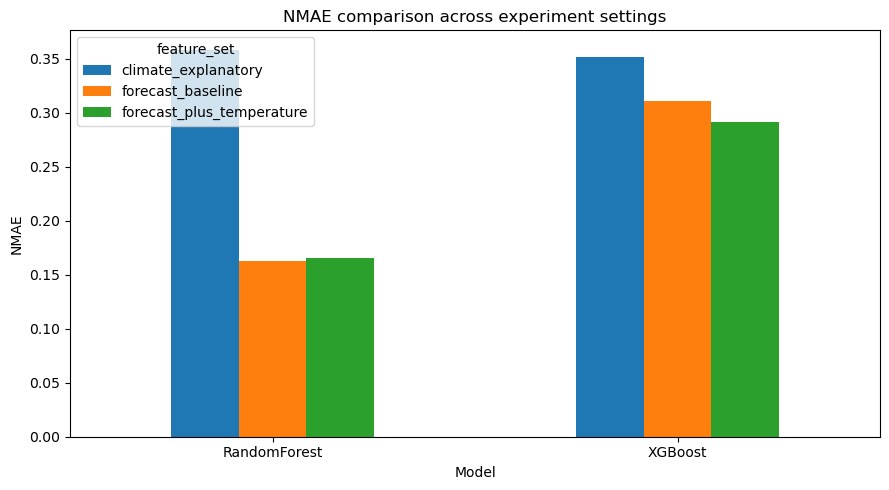

In [35]:
ax = results_df.pivot(index="model", columns="feature_set", values="NMAE").plot(
    kind="bar",
    figsize=(9, 5)
)
ax.set_title("NMAE comparison across experiment settings")
ax.set_ylabel("NMAE")
ax.set_xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 24. Global feature importance

This section shows which variables the models rely on most strongly under each experimental setting.

In [36]:
display(importance_df.head())

,feature,importance_mean,importance_std,feature_set,model,experiment
0,lag_2,1.105964,0.085682,forecast_baseline,RandomForest,forecast_baseline
1,lag_4,0.023025,0.003448,forecast_baseline,RandomForest,forecast_baseline
2,latitude,0.020596,0.002840,forecast_baseline,RandomForest,forecast_baseline
3,lag_1,0.020360,0.001897,forecast_baseline,RandomForest,forecast_baseline
4,lag_3,0.013422,0.001881,forecast_baseline,RandomForest,forecast_baseline


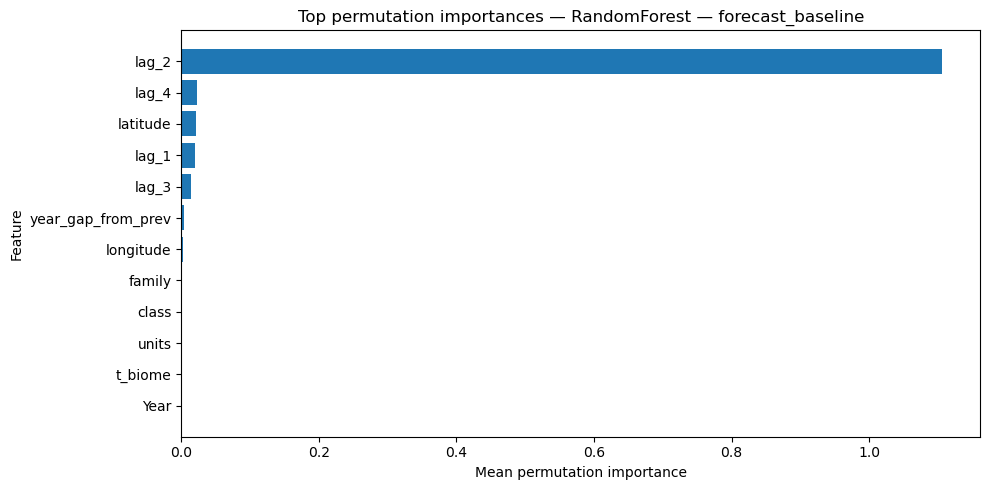

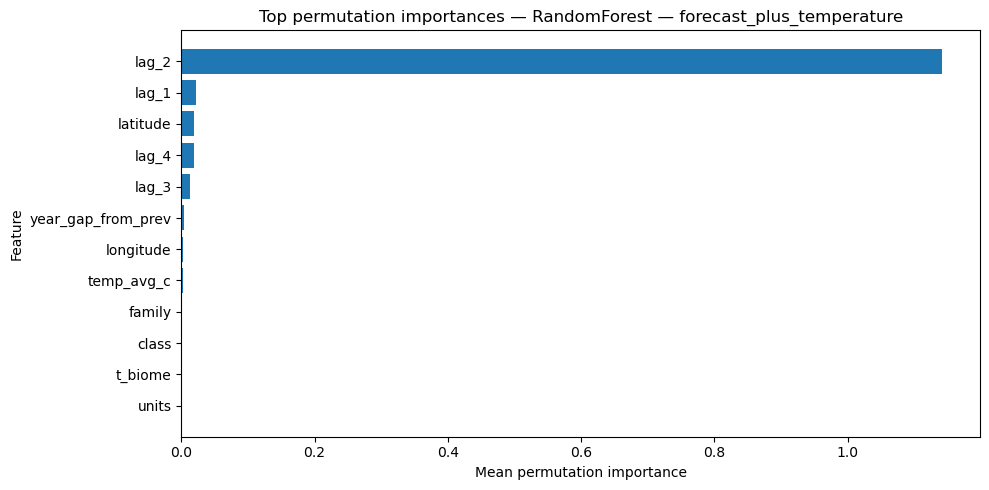

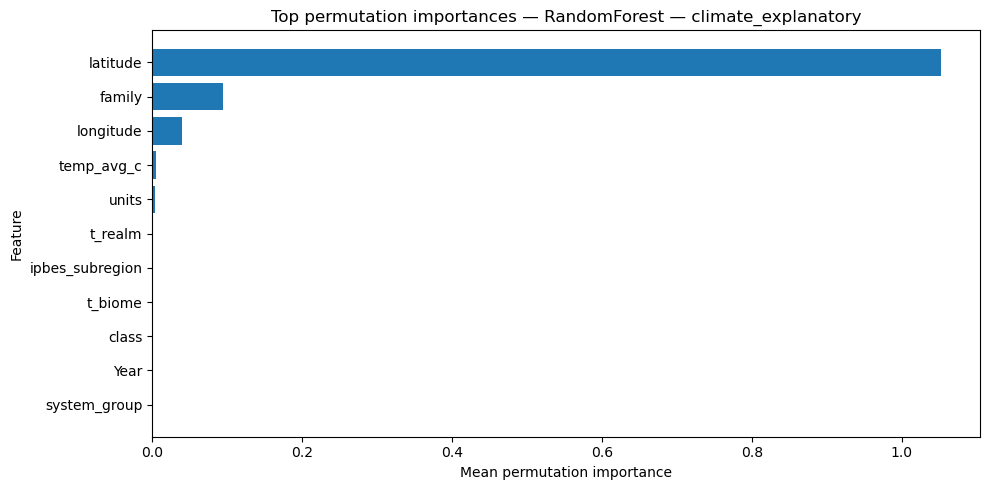

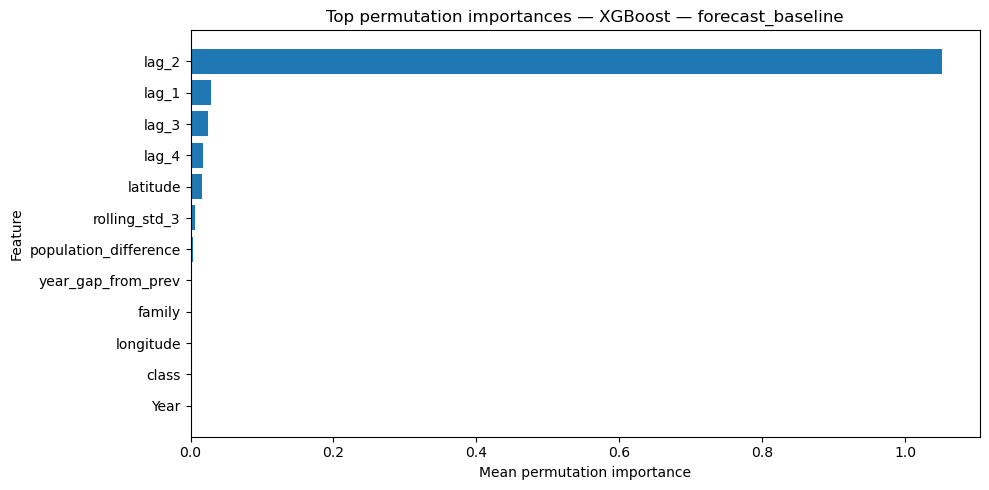

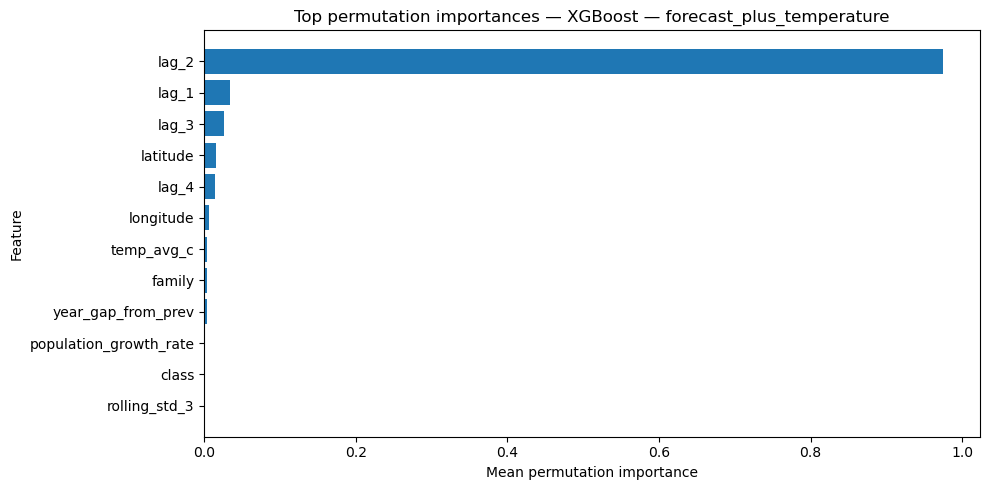

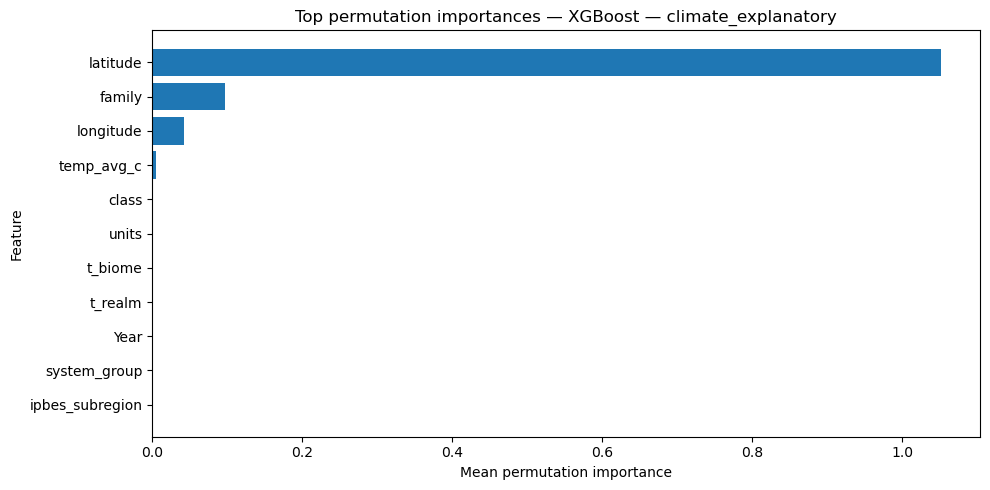

In [37]:
for model_name in importance_df["model"].unique():
    for feature_set in importance_df["feature_set"].unique():
        plot_df = (
            importance_df[
                (importance_df["model"] == model_name) &
                (importance_df["feature_set"] == feature_set)
            ]
            .sort_values("importance_mean", ascending=False)
            .head(12)
            .sort_values("importance_mean", ascending=True)
        )

        plt.figure(figsize=(10, 5))
        plt.barh(plot_df["feature"], plot_df["importance_mean"])
        plt.title(f"Top permutation importances — {model_name} — {feature_set}")
        plt.xlabel("Mean permutation importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

## 25. Climate-specific importance

To isolate the climate signal, we inspect only the temperature-derived variables.

In [38]:
climate_feature_names = ["temp_avg_c"]

climate_only_importance = importance_df[
    importance_df["feature"].isin(climate_feature_names)
].sort_values(["model", "feature_set", "importance_mean"], ascending=[True, True, False])

display(climate_only_importance)

,feature,importance_mean,importance_std,feature_set,model,experiment
81,temp_avg_c,0.005598,0.009657,climate_explanatory,RandomForest,climate_explanatory
45,temp_avg_c,0.001679,0.000945,forecast_plus_temperature,RandomForest,forecast_plus_temperature
92,temp_avg_c,0.004959,0.006486,climate_explanatory,XGBoost,climate_explanatory
64,temp_avg_c,0.004107,0.000844,forecast_plus_temperature,XGBoost,forecast_plus_temperature


## 26. Climate coverage diagnostics

We inspect how much of the biodiversity panel receives temperature data over time.

In [39]:
coverage_by_year = (
    model_long.groupby("Year")["temp_avg_c"]
    .apply(lambda x: x.notna().mean())
    .reset_index(name="share_with_temp")
)

display(coverage_by_year.head(20))

,Year,share_with_temp
0,1982,1.0
1,1983,1.0
2,1984,1.0
3,1985,1.0
4,1986,1.0
5,1987,1.0
6,1988,1.0
7,1989,1.0
8,1990,1.0
9,1991,1.0


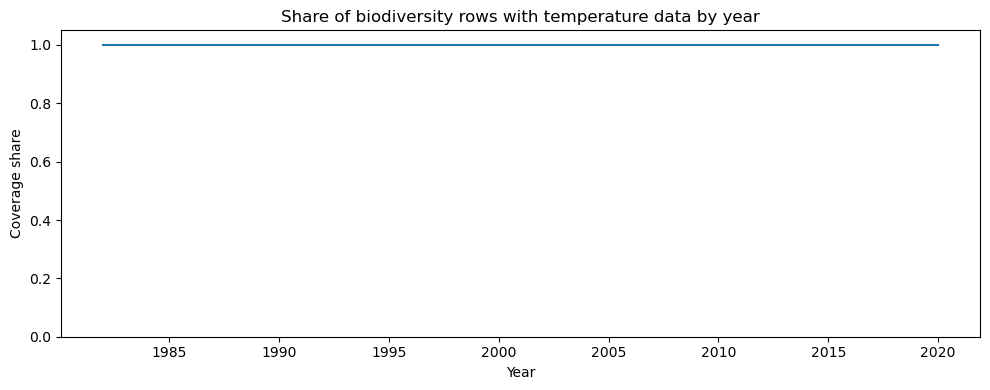

In [40]:
plt.figure(figsize=(10, 4))
plt.plot(coverage_by_year["Year"], coverage_by_year["share_with_temp"])
plt.title("Share of biodiversity rows with temperature data by year")
plt.xlabel("Year")
plt.ylabel("Coverage share")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 27. Interpretation of outcomes

This notebook compares three complementary scenarios:

- **forecast_baseline**: short-horizon forecasting using lags and metadata
- **forecast_plus_temperature**: same forecasting setting with temperature features
- **climate_explanatory**: no lagged population history, only metadata and climate

### How to interpret results

- If `forecast_plus_temperature` outperforms `forecast_baseline`, temperature adds predictive signal beyond recent population history.
- If `climate_explanatory` retains some predictive power, climate carries standalone explanatory relevance.
- If climate features have low global importance, this does not necessarily mean they are irrelevant for every population. Their effect may still be important locally or in specific ecological contexts.

## 28. Prepare application example

To demonstrate a future API/UI use case, we select one monitored population and apply the top short-horizon models to it.

In [41]:
def fit_models_for_feature_set(df, feature_columns, categorical_features, label="experiment"):
    train_df, test_df, test_year_values = temporal_split(df, test_years=TEST_YEARS)

    X_train = train_df[feature_columns]
    y_train = train_df["log_population"]

    X_test = test_df[feature_columns]
    y_test = test_df["Population"]

    cv_years = sorted(train_df["Year"].unique())
    split_year = cv_years[int(len(cv_years) * 0.8)]

    cv_train_idx = np.where(train_df["Year"] <= split_year)[0]
    cv_val_idx = np.where(train_df["Year"] > split_year)[0]
    cv_splits = [(cv_train_idx, cv_val_idx)]

    numeric_features = [c for c in feature_columns if c not in categorical_features]
    preprocessor = make_preprocessor(numeric_features, categorical_features)

    models = {
        "RandomForest": (
            Pipeline([
                ("prep", preprocessor),
                ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
            ]),
            {
                "model__n_estimators": [200],
                "model__max_depth": [8, None]
            }
        ),
        "XGBoost": (
            Pipeline([
                ("prep", preprocessor),
                ("model", XGBRegressor(
                    random_state=RANDOM_STATE,
                    objective="reg:squarederror",
                    n_estimators=200,
                    tree_method="hist",
                    n_jobs=-1
                ))
            ]),
            {
                "model__max_depth": [4, 8],
                "model__learning_rate": [0.05, 0.1]
            }
        )
    }

    fitted = {}
    summary_rows = []

    for model_name, (pipeline, param_grid) in models.items():
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="neg_mean_absolute_error",
            cv=cv_splits,
            n_jobs=-1,
            refit=True
        )

        grid.fit(X_train, y_train)

        preds_log = grid.best_estimator_.predict(X_test)
        preds = np.expm1(preds_log)
        preds = np.clip(preds, a_min=0, a_max=None)

        metrics = evaluate(y_test.to_numpy(), preds)

        summary_rows.append({
            "feature_set": label,
            "model": model_name,
            "best_params": str(grid.best_params_),
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "NMAE": metrics["NMAE"],
            "WAPE": metrics["WAPE"],
            "sMAPE": metrics["sMAPE"]
        })

        fitted[model_name] = grid.best_estimator_

    summary_df = pd.DataFrame(summary_rows).sort_values("NMAE")
    return fitted, summary_df, train_df, test_df

## 29. Fit the short-horizon climate-augmented models

In [42]:
feature_bundle = build_feature_columns(
    model_long,
    include_lags=True,
    include_climate=True,
    static_numeric_features=static_numeric_features,
    static_categorical_features=static_categorical_features,
    n_lags=N_LAGS
)

fitted_models, fitted_summary, train_df, test_df = fit_models_for_feature_set(
    model_long,
    feature_bundle["feature_columns"],
    feature_bundle["categorical_features"],
    label="forecast_plus_temperature"
)

display(fitted_summary)

,feature_set,model,best_params,MAE,RMSE,NMAE,WAPE,sMAPE
0,forecast_plus_temperature,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",5.744950,15.650684,0.165653,0.165653,0.923913
1,forecast_plus_temperature,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",10.096309,35.612561,0.291123,0.291123,0.967915


## 30. Select one example population

We select one sufficiently long population time series to demonstrate an application-style output.

In [43]:
series_lengths = (
    model_long.groupby("series_id")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="n_rows")
)

display(series_lengths.head(20))

,series_id,n_rows
0,Malleefowl|australia,949
1,Yellow-footed Rock-wallaby|australia,76
2,Wolverine|finland,60
3,Leadbeater's Possum|australia,56
4,Helmeted Honeyeater|australia,47
5,Mountain Pygmy-possum|australia,35
6,Moose|canada,32
7,Wolverine|norway,19
8,Wolverine|sweden,19
9,Plains-wanderer|australia,16


In [44]:
EXAMPLE_SERIES_ID = series_lengths.iloc[0]["series_id"]
print("Selected example series:", EXAMPLE_SERIES_ID)

Selected example series: Malleefowl|australia


## 31. Population metadata

This metadata block is useful for future API/UI integration.

In [45]:
def get_series_metadata(df, series_id):
    cols = [
        "series_id", "binomial", "common_name", "class", "family",
        "country", "location", "units", "t_realm", "t_biome", "ipbes_subregion"
    ]
    cols = [c for c in cols if c in df.columns]

    meta = (
        df[df["series_id"] == series_id][cols]
        .drop_duplicates()
        .head(1)
        .T
        .reset_index()
    )
    meta.columns = ["field", "value"]
    return meta

In [46]:
display(get_series_metadata(model_long, EXAMPLE_SERIES_ID))

,field,value
0,series_id,Malleefowl|australia
1,binomial,Leipoa_ocellata
2,common_name,Malleefowl
3,class,Aves
4,family,Megapodiidae
5,country,australia
6,location,Lowan Mallee
7,units,proxy: breeding pairs
8,t_realm,Australasia
9,t_biome,"Mediterranean forests, woodlands and scrub"


## 32. Held-out rows for the selected population

We use the current short-horizon test horizon already defined in the notebook.

In [47]:
example_test = (
    test_df[test_df["series_id"] == EXAMPLE_SERIES_ID]
    .sort_values("Year")
    .copy()
)

display(example_test[
    ["series_id", "Year", "Population", "temp_avg_c", "temp_change_1y"]
].head(20))

,series_id,Year,Population,temp_avg_c,temp_change_1y
25,Malleefowl|australia,2016,0.0,22.401682,-0.104718
26,Malleefowl|australia,2016,0.0,22.401682,-0.104718
27,Malleefowl|australia,2016,3.0,22.401682,-0.104718
28,Malleefowl|australia,2016,0.0,22.401682,-0.104718
29,Malleefowl|australia,2016,0.0,22.401682,-0.104718
30,Malleefowl|australia,2016,1.0,22.401682,-0.104718
31,Malleefowl|australia,2016,0.0,22.401682,-0.104718
32,Malleefowl|australia,2016,3.0,22.401682,-0.104718
33,Malleefowl|australia,2016,0.0,22.401682,-0.104718
34,Malleefowl|australia,2016,3.0,22.401682,-0.104718


## 33. Short-horizon predictions for the selected population

In [48]:
X_example = example_test[feature_bundle["feature_columns"]].copy()

for model_name, estimator in fitted_models.items():
    pred_log = estimator.predict(X_example)
    example_test[f"pred_{model_name}"] = np.clip(np.expm1(pred_log), a_min=0, a_max=None)

display(example_test[
    ["series_id", "Year", "Population", "pred_RandomForest", "pred_XGBoost"]
].head(20))

,series_id,Year,Population,pred_RandomForest,pred_XGBoost
25,Malleefowl|australia,2016,0.0,0.692611,0.908845
26,Malleefowl|australia,2016,0.0,0.350207,0.324999
27,Malleefowl|australia,2016,3.0,1.613382,1.612440
28,Malleefowl|australia,2016,0.0,1.267310,1.193167
29,Malleefowl|australia,2016,0.0,3.028003,3.164169
30,Malleefowl|australia,2016,1.0,2.291714,1.497031
31,Malleefowl|australia,2016,0.0,0.839317,0.705382
32,Malleefowl|australia,2016,3.0,0.851962,1.644201
33,Malleefowl|australia,2016,0.0,2.652909,2.213626
34,Malleefowl|australia,2016,3.0,2.529823,2.406651


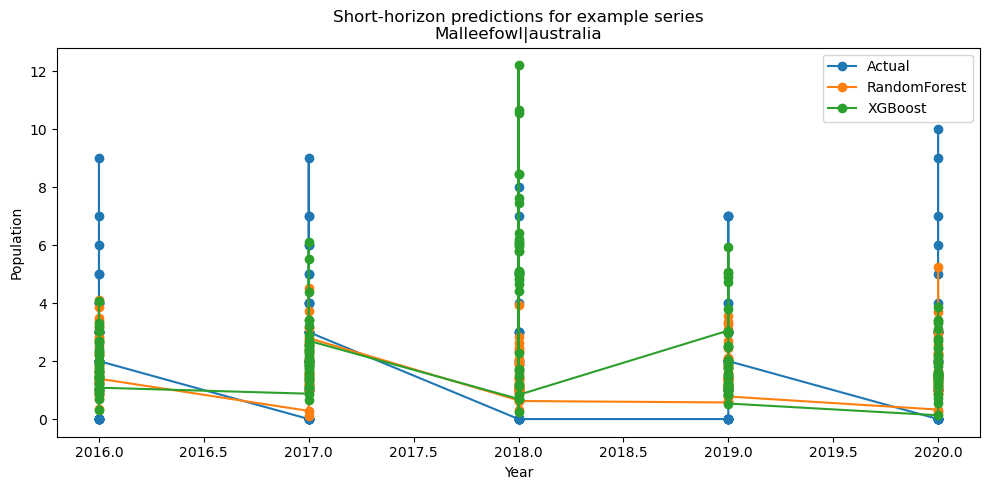

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(example_test["Year"], example_test["Population"], marker="o", label="Actual")
plt.plot(example_test["Year"], example_test["pred_RandomForest"], marker="o", label="RandomForest")
plt.plot(example_test["Year"], example_test["pred_XGBoost"], marker="o", label="XGBoost")
plt.title(f"Short-horizon predictions for example series\n{EXAMPLE_SERIES_ID}")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.tight_layout()
plt.show()

## 34. Model-based climate contribution

To estimate how much climate is influencing the model prediction for this population, we compare:

- prediction under the observed temperature values
- prediction under a neutralized temperature scenario

This is a **model sensitivity measure**, not a causal effect estimate.

In [50]:
def neutralize_temperature_features(df, climate_cols):
    df_cf = df.copy()
    for col in climate_cols:
        if col in df_cf.columns:
            df_cf[col] = df_cf[col].median()
    return df_cf

In [51]:
climate_cols = ["temp_avg_c"]
climate_cols = [c for c in climate_cols if c in feature_bundle["feature_columns"]]

In [52]:
X_example_real = example_test[feature_bundle["feature_columns"]].copy()
X_example_neutral = neutralize_temperature_features(X_example_real, climate_cols)

for model_name, estimator in fitted_models.items():
    pred_real = np.clip(np.expm1(estimator.predict(X_example_real)), a_min=0, a_max=None)
    pred_neutral = np.clip(np.expm1(estimator.predict(X_example_neutral)), a_min=0, a_max=None)

    example_test[f"pred_{model_name}_real"] = pred_real
    example_test[f"pred_{model_name}_neutral_climate"] = pred_neutral
    example_test[f"climate_effect_abs_{model_name}"] = pred_real - pred_neutral
    example_test[f"climate_effect_pct_{model_name}"] = np.where(
        pred_neutral != 0,
        100 * (pred_real - pred_neutral) / pred_neutral,
        np.nan
    )

display(example_test[
    ["Year", "Population"]
    + [c for c in example_test.columns if "climate_effect" in c]
].head(20))

,Year,Population,climate_effect_abs_RandomForest,climate_effect_pct_RandomForest,climate_effect_abs_XGBoost,climate_effect_pct_XGBoost
25,2016,0.0,-0.002235,-0.321716,0.000000,0.000000
26,2016,0.0,0.016484,4.939440,0.000000,0.000000
27,2016,3.0,-0.060764,-3.629545,0.035104,2.225511
28,2016,0.0,-0.166476,-11.610922,0.000000,0.000000
29,2016,0.0,0.204262,7.233719,0.000000,0.000000
30,2016,1.0,-0.027204,-1.173145,0.000000,0.000000
31,2016,0.0,-0.148795,-15.058533,0.000000,0.000000
32,2016,3.0,-0.051317,-5.681182,0.000000,0.000000
33,2016,0.0,-0.314224,-10.590150,0.000000,0.000000
34,2016,3.0,0.095586,3.926717,0.000000,0.000000


## 35. Climate contribution visualization

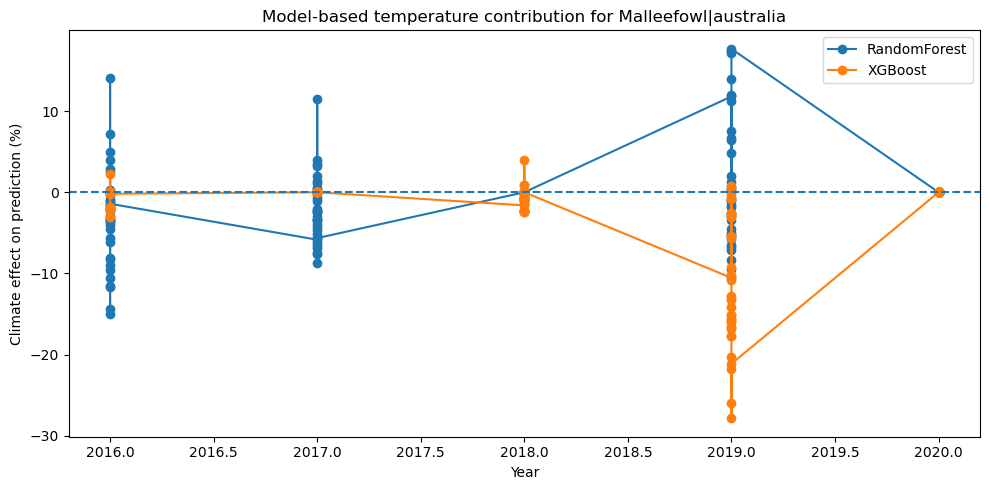

In [53]:
plt.figure(figsize=(10, 5))
plt.plot(example_test["Year"], example_test["climate_effect_pct_RandomForest"], marker="o", label="RandomForest")
plt.plot(example_test["Year"], example_test["climate_effect_pct_XGBoost"], marker="o", label="XGBoost")
plt.axhline(0, linestyle="--")
plt.title(f"Model-based temperature contribution for {EXAMPLE_SERIES_ID}")
plt.xlabel("Year")
plt.ylabel("Climate effect on prediction (%)")
plt.legend()
plt.tight_layout()
plt.show()

## 36. Application-oriented interpretation

For a future API/UI, a selected population could return:

- predicted abundance at the chosen forecast horizon
- historical abundance trend
- species and population metadata
- leading model drivers
- model-based climate contribution
- direction of climate pressure:
  - positive
  - negative
  - negligible

In the current notebook, climate contribution is reported as a **prediction sensitivity measure**.

For example, if the model predicts a value 8% lower under the observed temperature profile than under a neutralized climate scenario, temperature is pushing the model prediction downward by 8% for that observation.

This should not be interpreted as causal proof that temperature caused the real-world decline.

## 37. Limitations

This notebook provides a first climate integration layer, but several limitations remain:

- Climate data are currently matched at the **country-year** level, which may be coarse for locally monitored populations.
- The forecasting setup currently follows the existing **short-horizon** workflow rather than the future long-horizon extension.
- Climate contribution estimates are **model-based sensitivity measures**, not causal effect estimates.
- Temperature is only the first climate covariate; future versions should include additional drivers such as precipitation, anomalies, and extremes.

## 38. Next extensions

This notebook is designed to remain modular. Natural next steps include:

- adding precipitation
- adding anomaly-based climate indicators
- adding climate variability or extreme-event features
- testing interactions between climate and biome/realm/system group
- integrating the same climate pipeline into the future 20-year forecasting workflow
- exposing model outputs through an API/UI at the population level

In [54]:
import hashlib

def dataframe_fingerprint(df):
    # Ordina per stabilità
    df_sorted = df.sort_values(["series_id", "Year"]).reset_index(drop=True)

    # Converti in stringa compatta
    data_str = df_sorted.to_csv(index=False)

    # Hash
    return hashlib.md5(data_str.encode()).hexdigest()

print("MODEL_LONG FINGERPRINT:")
print(dataframe_fingerprint(model_long))

MODEL_LONG FINGERPRINT:
99f9f3eda7c8bdc28c37d0b42b17269e


In [55]:
print("FEATURE COLUMNS:")
print(sorted(feature_bundle["feature_columns"]))

import hashlib
print("FEATURE HASH:")
print(hashlib.md5(str(sorted(feature_bundle["feature_columns"])).encode()).hexdigest())

FEATURE COLUMNS:
['Year', 'class', 'family', 'ipbes_subregion', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'latitude', 'longitude', 'population_difference', 'population_growth_rate', 'rolling_mean_3', 'rolling_std_3', 'system_group', 't_biome', 't_realm', 'temp_avg_c', 'units', 'year_gap_from_prev']
FEATURE HASH:
af6880b751c9024ca54fbf7f6042827e


In [56]:
train_df, test_df, _ = temporal_split(model_long, test_years=TEST_YEARS)

print("TRAIN FINGERPRINT:")
print(dataframe_fingerprint(train_df))

print("TEST FINGERPRINT:")
print(dataframe_fingerprint(test_df))

TRAIN FINGERPRINT:
ea54bdf5aef527b57cad1d20ab56a030
TEST FINGERPRINT:
ade8902fbb9b0633ca2d9bc01aae169d
